<a href="https://colab.research.google.com/github/lena-33/Prediction_of_Product_Sales/blob/main/Prediction_of_Product_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediction of Product Sales
 - Author: Lina Thabet


## Project Overview

## Load and Inspect Data

In [174]:
import pandas as pd
import numpy as np

In [72]:
path = "/content/drive/MyDrive/AXSOSACADEMY/01-Fundamentals/Week02/Data/sales_predictions_2023.csv"
df = pd.read_csv(path)

In [73]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [75]:
df_ins = df.copy()

In [76]:
df_2 = df.copy()

## Clean Data

In [77]:
df.duplicated().sum()

np.int64(0)

In [78]:
df.isna().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [79]:
df.isna().sum() / len(df) * 100

,0
Item_Identifier,0.000000
Item_Weight,17.165317
Item_Fat_Content,0.000000
Item_Visibility,0.000000
Item_Type,0.000000
Item_MRP,0.000000
Outlet_Identifier,0.000000
Outlet_Establishment_Year,0.000000
Outlet_Size,28.276428
Outlet_Location_Type,0.000000


In [80]:
df['Item_Weight'].describe()

,Item_Weight
count,7060.000000
mean,12.857645
std,4.643456
min,4.555000
25%,8.773750
50%,12.600000
75%,16.850000
max,21.350000


In [81]:
med = df['Item_Weight'].median()

In [82]:
df['Item_Weight'] = df['Item_Weight'].replace(-1, med)

In [83]:
df['Item_Weight'].value_counts()

,count
Item_Weight,
12.150,86
17.600,82
13.650,77
11.800,76
15.100,68
...,...
8.920,2
6.520,1
9.420,1


In [84]:
df['Item_Weight'].isna().sum()

np.int64(1463)

In [85]:
df['Outlet_Size'] = df['Outlet_Size'].fillna(-1)

In [86]:
df['Outlet_Size'].isna().sum()

np.int64(0)

In [87]:
string_col = df.select_dtypes('object').columns
string_col

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

In [88]:
for i in string_col:
  print('The column :', df[i].value_counts() , '\n')

The column : Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64 

The column : Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64 

The column : Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64 

The column : Outlet_Identifier
OUT027    935
OUT013    932
OUT035    930
OUT049    930
OUT046    930
OUT045    929
OUT018    928

In [89]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace('LF','Low Fat')

In [90]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace('reg','Regular')

In [91]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace('low fat','Low Fat')

In [92]:
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


In [93]:
number_col = df.select_dtypes('number').columns
number_col

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales'],
      dtype='object')

In [94]:
for i in number_col:
  print(f'The column :{i}\n', df[i].describe() , '\n')

The column :Item_Weight
 count    7060.000000
mean       12.857645
std         4.643456
min         4.555000
25%         8.773750
50%        12.600000
75%        16.850000
max        21.350000
Name: Item_Weight, dtype: float64 

The column :Item_Visibility
 count    8523.000000
mean        0.066132
std         0.051598
min         0.000000
25%         0.026989
50%         0.053931
75%         0.094585
max         0.328391
Name: Item_Visibility, dtype: float64 

The column :Item_MRP
 count    8523.000000
mean      140.992782
std        62.275067
min        31.290000
25%        93.826500
50%       143.012800
75%       185.643700
max       266.888400
Name: Item_MRP, dtype: float64 

The column :Outlet_Establishment_Year
 count    8523.000000
mean     1997.831867
std         8.371760
min      1985.000000
25%      1987.000000
50%      1999.000000
75%      2004.000000
max      2009.000000
Name: Outlet_Establishment_Year, dtype: float64 

The column :Item_Outlet_Sales
 count     8523.000000
m

In [95]:
df.describe().round(2)

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.00,8523.00,8523.00,8523.00,8523.00
mean,12.86,0.07,140.99,1997.83,2181.29
std,4.64,0.05,62.28,8.37,1706.50
min,4.56,0.00,31.29,1985.00,33.29
25%,8.77,0.03,93.83,1987.00,834.25
50%,12.60,0.05,143.01,1999.00,1794.33
75%,16.85,0.09,185.64,2004.00,3101.30
max,21.35,0.33,266.89,2009.00,13086.96


## Exploratory Data Analysis

In [96]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,-1,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [97]:
df.select_dtypes('number').columns

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales'],
      dtype='object')

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

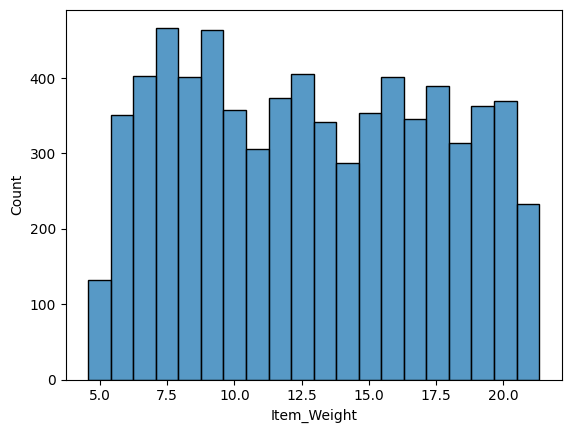

In [99]:
sns.histplot(data=df , x='Item_Weight');

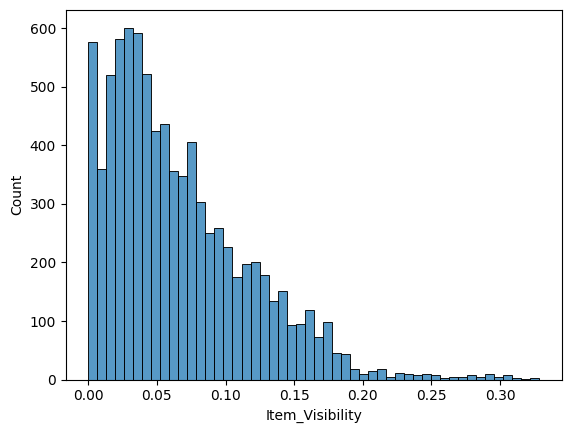

In [100]:
sns.histplot(data=df , x='Item_Visibility');

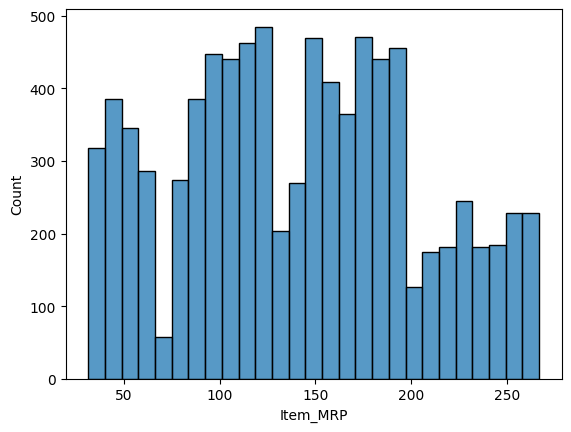

In [101]:
sns.histplot(data=df , x='Item_MRP');

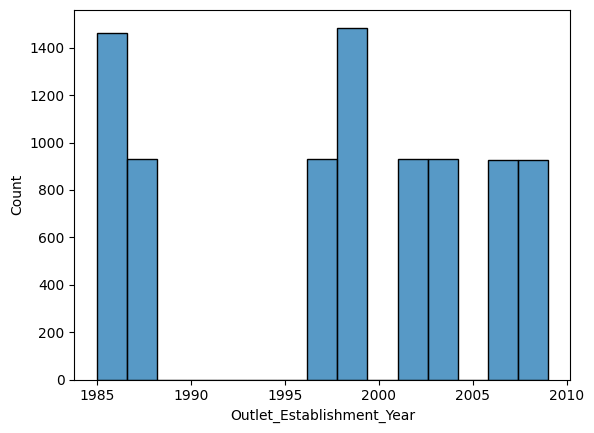

In [102]:
sns.histplot(data=df , x='Outlet_Establishment_Year');

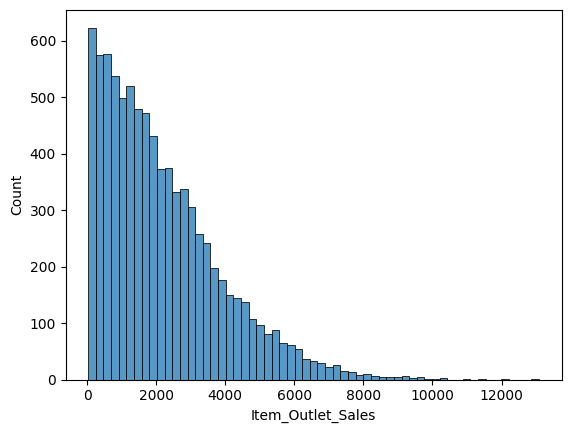

In [103]:
sns.histplot(data=df , x='Item_Outlet_Sales');

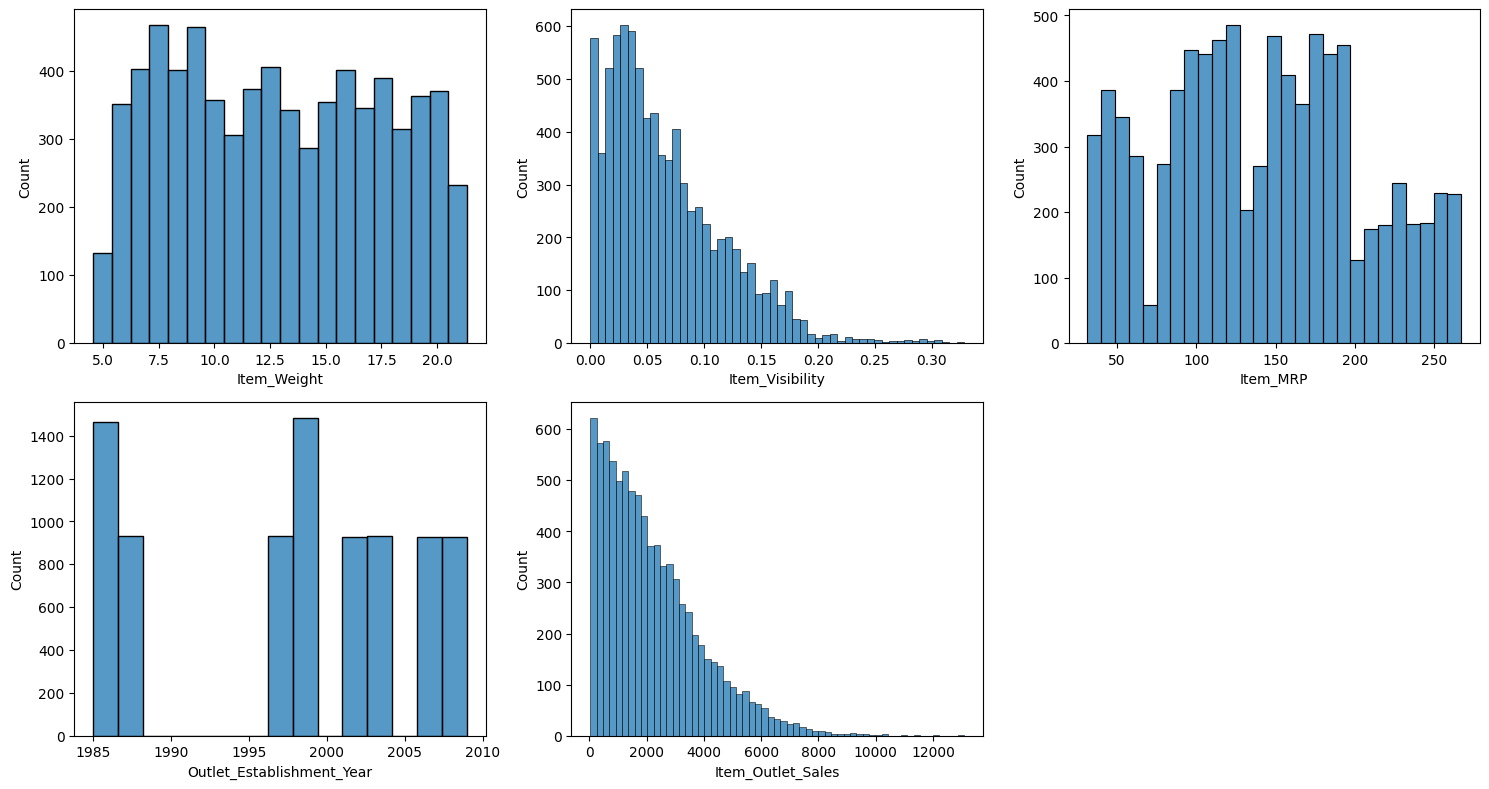

In [104]:
fig, axes = plt.subplots(ncols=3 , nrows=2, figsize=(15, 8))
sns.histplot(data=df , x='Item_Weight',ax=axes[0,0])
sns.histplot(data=df , x='Item_Visibility',ax=axes[0,1])
sns.histplot(data=df , x='Item_MRP',ax=axes[0,2])
sns.histplot(data=df , x='Outlet_Establishment_Year',ax=axes[1,0])
sns.histplot(data=df , x='Item_Outlet_Sales',ax=axes[1,1])

# Remove the unused 6th subplot
fig.delaxes(axes[1,2])

fig.tight_layout();

- This set of histograms displays the distribution of several numerical features: 'Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year', and 'Item_Outlet_Sales'. These plots help to understand the shape of the data, central tendency, and spread for each variable.

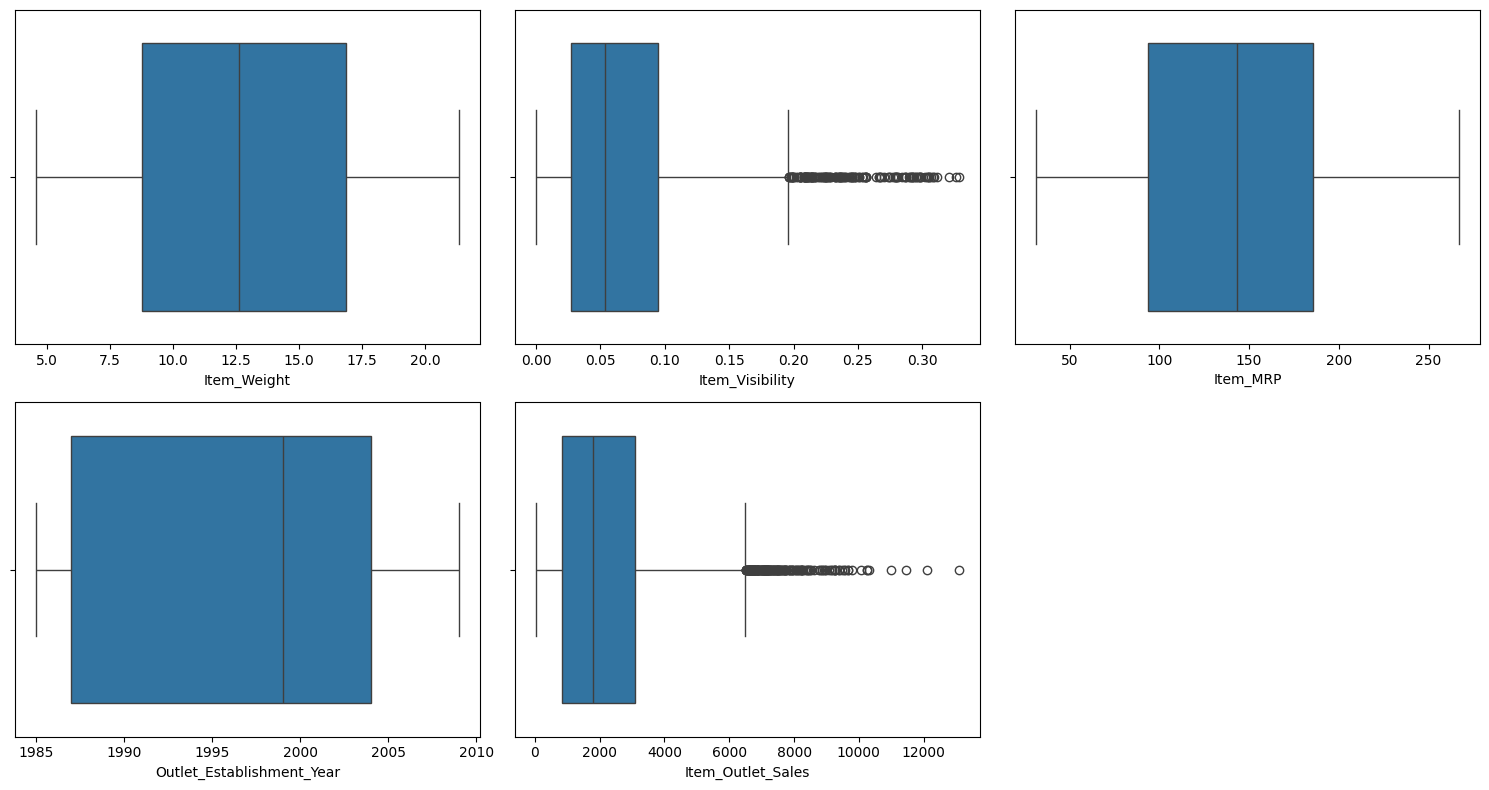

In [105]:
fig, axes = plt.subplots(ncols=3 , nrows=2, figsize=(15, 8))
sns.boxplot(data=df , x='Item_Weight',ax=axes[0,0])
sns.boxplot(data=df , x='Item_Visibility',ax=axes[0,1])
sns.boxplot(data=df , x='Item_MRP',ax=axes[0,2])
sns.boxplot(data=df , x='Outlet_Establishment_Year',ax=axes[1,0])
sns.boxplot(data=df , x='Item_Outlet_Sales',ax=axes[1,1])

fig.delaxes(axes[1,2])

fig.tight_layout();

- This set of boxplots visualizes the distribution and potential outliers for numerical features: 'Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year', and 'Item_Outlet_Sales'. Boxplots provide a good summary of the five-number summary (minimum, first quartile, median, third quartile, and maximum) and highlight any extreme values.

In [106]:
df.select_dtypes('object').columns

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

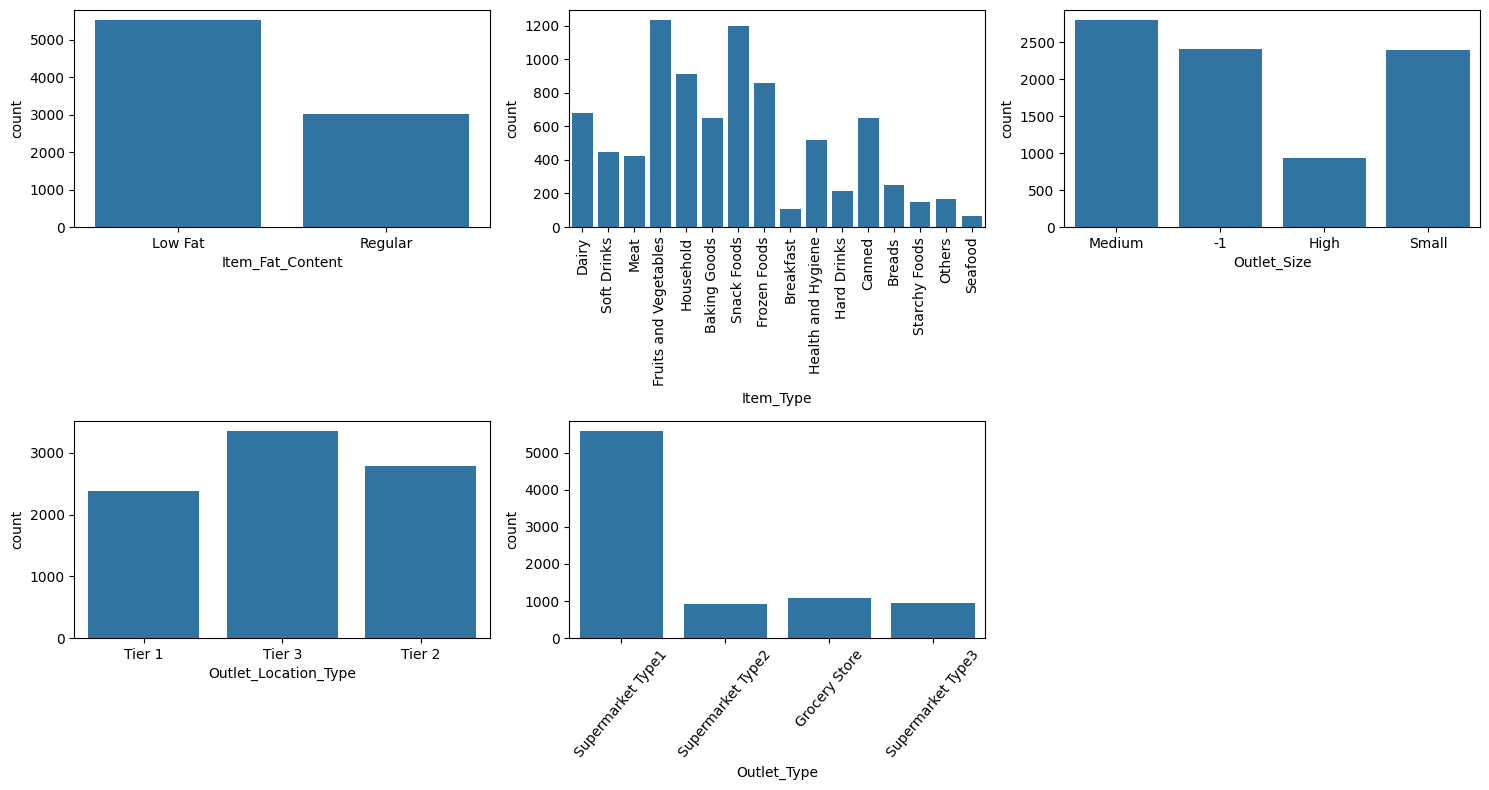

In [107]:
fig, axes = plt.subplots(ncols=3 , nrows=2, figsize=(15, 8))
sns.countplot(data=df , x='Item_Fat_Content',ax=axes[0,0])
sns.countplot(data=df , x='Item_Type',ax=axes[0,1])
axes[0,1].tick_params(axis='x' , rotation=90)
sns.countplot(data=df , x='Outlet_Size',ax=axes[0,2])
sns.countplot(data=df , x='Outlet_Location_Type',ax=axes[1,0])
sns.countplot(data=df , x='Outlet_Type',ax=axes[1,1])
axes[1,1].tick_params(axis='x' , rotation=50)


fig.delaxes(axes[1,2])

fig.tight_layout();

- This set of countplots shows the frequency distribution of categorical features: 'Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type', and 'Outlet_Type'. These plots illustrate the number of occurrences for each category within these features.

In [108]:
corr = df.corr(numeric_only=True)
corr.round(2)

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
Item_Weight,1.00,-0.01,0.03,-0.01,0.01
Item_Visibility,-0.01,1.00,-0.00,-0.07,-0.13
Item_MRP,0.03,-0.00,1.00,0.01,0.57
Outlet_Establishment_Year,-0.01,-0.07,0.01,1.00,-0.05
Item_Outlet_Sales,0.01,-0.13,0.57,-0.05,1.00


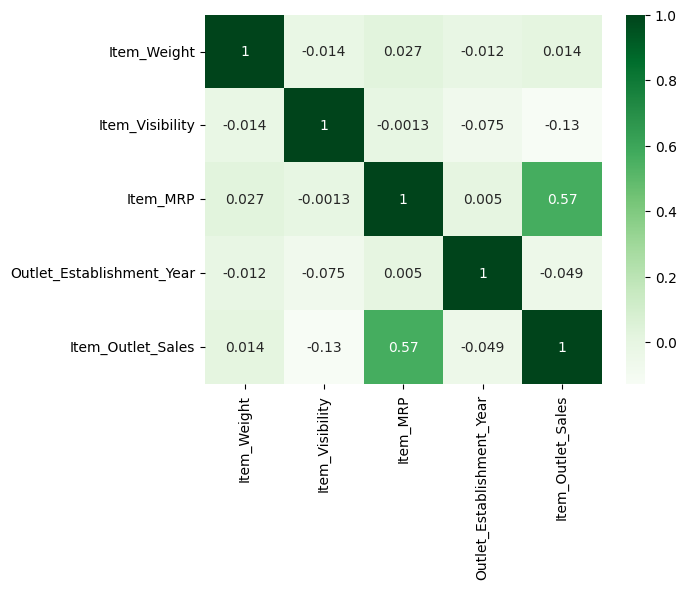

In [109]:
sns.heatmap(corr , annot=True , cmap='Greens');

- We can see their is a positive correlation between 'Item_MRP' & 'Item_Outlet_Sales'.

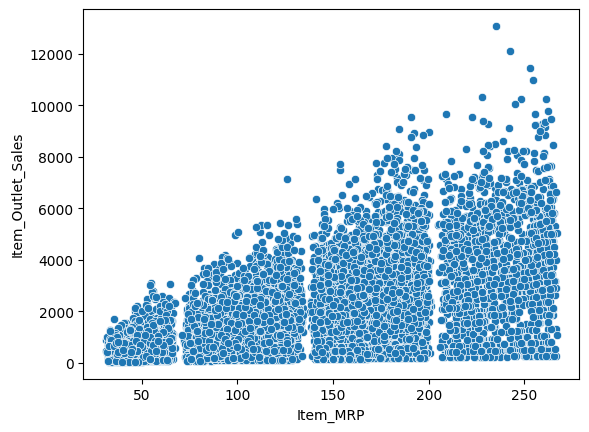

In [110]:
sns.scatterplot(data=df , x='Item_MRP' , y='Item_Outlet_Sales');

- We can see when Item_MRP increases the Item_Outlet_Sales also increase.

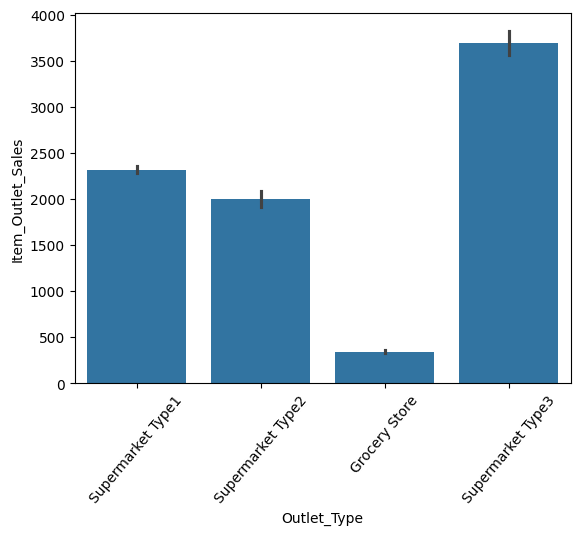

In [111]:
ax = sns.barplot(data=df , x='Outlet_Type' , y='Item_Outlet_Sales')
ax.tick_params(axis='x' , rotation=50)

- we can see the 'Supermarket Type3' has the highest sales.

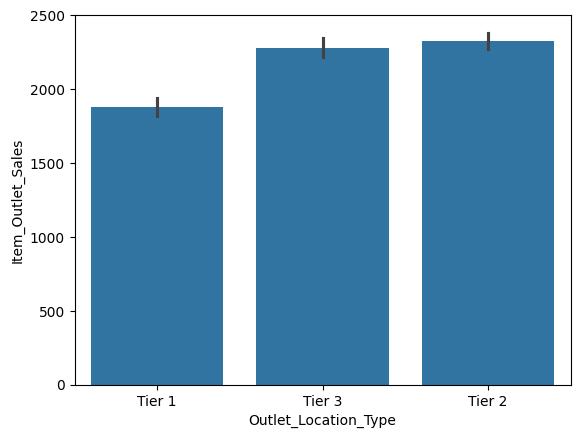

In [112]:
sns.barplot(data=df , x='Outlet_Location_Type' , y='Item_Outlet_Sales');

- we can see the 'Tier 2' has the highest sales, but not big difference from 'Tier 3'

## Feature inspection

In [113]:
def explore_categorical(df, x, fillna = True, placeholder = 'MISSING',
                        figsize = (6,4), order = None):
  temp_df = df.copy()
  null_count = temp_df[x].isna().sum()
  null_perc = null_count/len(temp_df)* 100
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  fig, ax = plt.subplots(figsize=figsize)
  sns.countplot(data=temp_df, x=x, ax=ax, order=order)
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
  ax.set_title(f"Column: {x}", fontweight='bold')
  fig.tight_layout()
  plt.show()

  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  nunique = temp_df[x].nunique()
  print(f"- Unique Values: {nunique}")
  val_counts = temp_df[x].value_counts(dropna=False)
  most_common_val = val_counts.index[0]
  freq = val_counts.values[0]
  perc_most_common = freq / len(temp_df) * 100
  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, ax


In [114]:
def explore_numeric(df, x, figsize=(6,5) ):
  null_count = df[x].isna().sum()
  null_perc = null_count/len(df)* 100
  gridspec = {'height_ratios':[0.7,0.3]}
  fig, axes = plt.subplots(nrows=2, figsize=figsize,sharex=True, gridspec_kw=gridspec)
  sns.histplot(data=df, x=x, ax=axes[0])
  sns.boxplot(data=df, x=x, ax=axes[1])
  axes[0].set_title(f"Column: {x}", fontweight='bold')

  fig.tight_layout()
  plt.show()


  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  nunique = df[x].nunique()
  print(f"- Unique Values: {nunique}")

  most_common_val_count = df[x].value_counts(dropna=False).head(1)
  most_common_val = most_common_val_count.index[0]
  freq = most_common_val_count.values[0]
  perc_most_common = freq / len(df) * 100

  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")

  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, axes

In [115]:

def plot_categorical_vs_target(df, x, y='rating',figsize=(6,4),
                            fillna = True, placeholder = 'MISSING',
                            order = None):
  temp_df = df.copy()
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  else:
    temp_df = temp_df.dropna(subset=[x])
  fig, ax = plt.subplots(figsize=figsize)

    # Barplot
  sns.barplot(data=temp_df, x=x, y=y, ax=ax, order=order, alpha=0.6,
              linewidth=1, edgecolor='black', errorbar=None)

  # Boxplot
  sns.stripplot(data=temp_df, x=x, y=y, hue=x, ax=ax,
                order=order, hue_order=order, legend=False,
                edgecolor='white', linewidth=0.5,
                size=3,zorder=0)
  # Rotate xlabels
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

  ax.set_title(f"{x} vs. {y}", fontweight='bold')
  fig.tight_layout()
  return fig, ax

In [116]:
def plot_numeric_vs_target(df, x, y='rating',
                           figsize=(6,4),
                           ):
  corr = df[[x,y]].corr().round(2)
  r = corr.loc[x,y]

  fig, ax = plt.subplots(figsize=figsize)
  scatter_kws={'ec':'white','linewidths':1,'alpha':0.8}
  sns.regplot(data=df, x=x, y=y, ax=ax, scatter_kws=scatter_kws)

  ax.set_title(f"{x} vs. {y} (r = {r})", fontweight='bold')
  plt.show()

  return fig, ax

In [117]:
df_ins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [118]:
df_ins.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [119]:
use_cols = ['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type','Item_Outlet_Sales']
df = df[use_cols]
df

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,9.300,Low Fat,0.016047,Dairy,249.8092,Medium,Tier 1,Supermarket Type1,3735.1380
1,5.920,Regular,0.019278,Soft Drinks,48.2692,Medium,Tier 3,Supermarket Type2,443.4228
2,17.500,Low Fat,0.016760,Meat,141.6180,Medium,Tier 1,Supermarket Type1,2097.2700
3,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,-1,Tier 3,Grocery Store,732.3800
4,8.930,Low Fat,0.000000,Household,53.8614,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...
8518,6.865,Low Fat,0.056783,Snack Foods,214.5218,High,Tier 3,Supermarket Type1,2778.3834
8519,8.380,Regular,0.046982,Baking Goods,108.1570,-1,Tier 2,Supermarket Type1,549.2850
8520,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,Small,Tier 2,Supermarket Type1,1193.1136
8521,7.210,Regular,0.145221,Snack Foods,103.1332,Medium,Tier 3,Supermarket Type2,1845.5976



- Define your target column:
  - Item_Outlet_Sales


## Inspecting Each Feature

1. Item_Weight

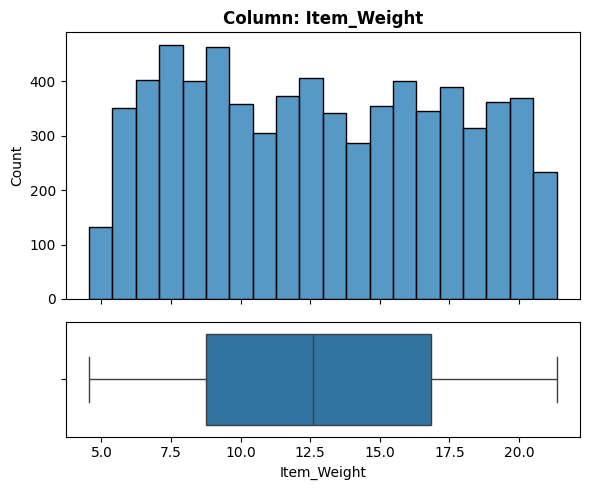

- NaN's Found: 1463 (17.17%)
- Unique Values: 415
- Most common value: 'nan' occurs 1463 times (17.17%)
- Not constant or quasi-constant.


In [120]:
explore_numeric(df,'Item_Weight');

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - Numeric

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 1463 null values (17.17%).
  - Impute with the median.

3. Is the feature constant or quasi-constant?
  - Not constant or quasi-constant.

4. What is the cardinality? Is it high?
  - 415 unique values. Not high.

5. Would we know this BEFORE the target is determined?
  - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  - No.

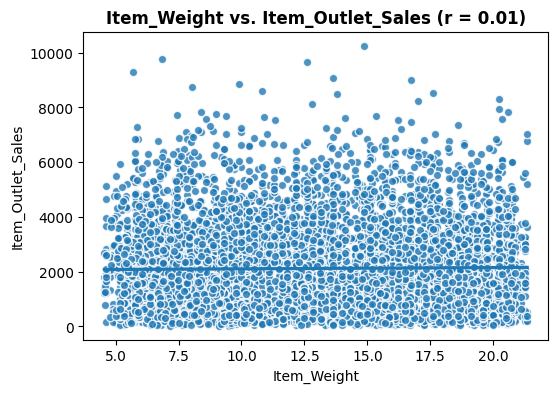

In [121]:
plot_numeric_vs_target(df,'Item_Weight', 'Item_Outlet_Sales');

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes, item weight might influence sales.
  - Does this feature appear to be a predictor of the target?
    - No strong apparent correlation (r=0.01).

---


---

2. Item_Fat_Content

/tmp/ipykernel_16475/3512767888.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


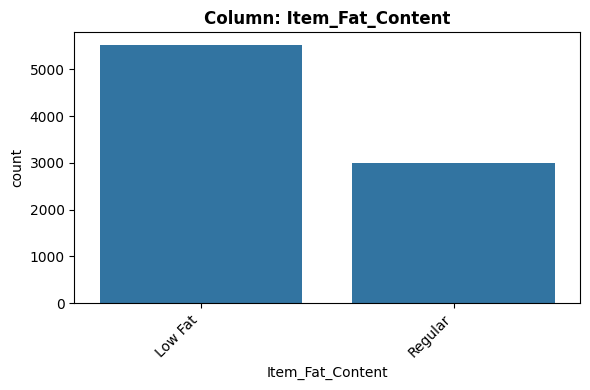

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: 'Low Fat' occurs 5517 times (64.73%)
- Not constant or quasi-constant.


In [122]:
explore_categorical(df,'Item_Fat_Content');

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - Categorical (nominal)

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0 null values (0%).
  - No action needed.

3. Is the feature constant or quasi-constant?
  - Not constant or quasi-constant.

4. What is the cardinality? Is it high?
  - 2 unique values. Not high.

5. Would we know this BEFORE the target is determined?
  - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  - No.

/tmp/ipykernel_16475/166905199.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


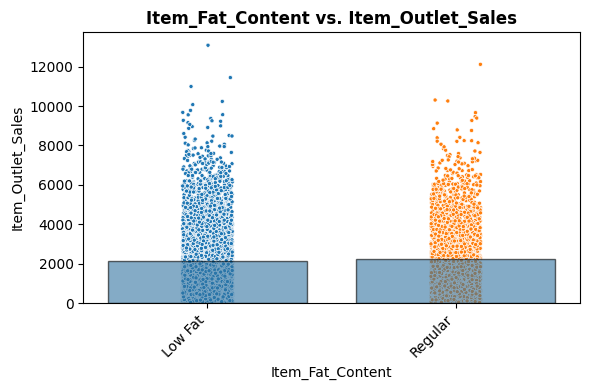

In [123]:
plot_categorical_vs_target(df, 'Item_Fat_Content','Item_Outlet_Sales');

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes, fat content could influence consumer preference and sales.
  - Does this feature appear to be a predictor of the target?
    - Slightly, 'Regular' fat content items seem to have slightly higher sales than 'Low Fat'.

---

---

3. Item_Visibility

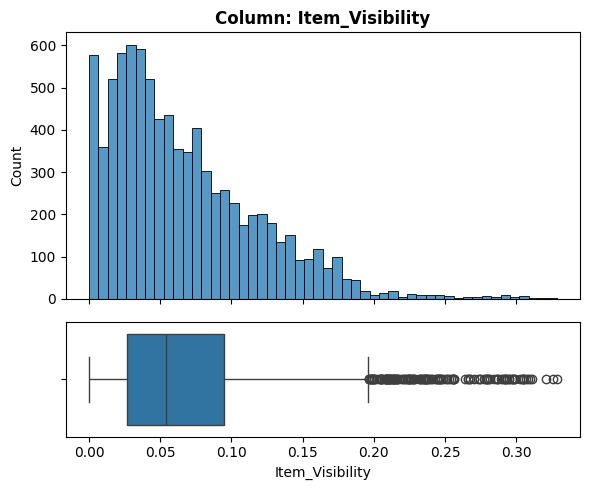

- NaN's Found: 0 (0.0%)
- Unique Values: 7880
- Most common value: '0.0' occurs 526 times (6.17%)
- Not constant or quasi-constant.


In [124]:
explore_numeric(df,'Item_Visibility');

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - Numeric

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0 null values (0%).
  - No action needed.

3. Is the feature constant or quasi-constant?
  - Not constant or quasi-constant.

4. What is the cardinality? Is it high?
  - 7880 unique values. High.

5. Would we know this BEFORE the target is determined?
  - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  - No.

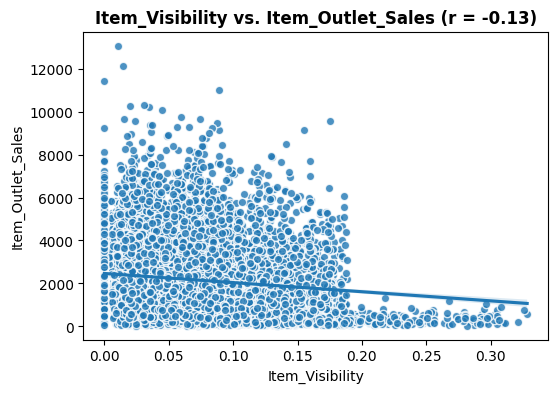

In [125]:
plot_numeric_vs_target(df,'Item_Visibility', 'Item_Outlet_Sales');

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes, higher visibility would ideally lead to higher sales.
  - Does this feature appear to be a predictor of the target?
    - Shows a weak negative correlation (r = -0.13), which is counter-intuitive and may indicate noise or other factors at play.

---

---

4. Item_Type

/tmp/ipykernel_16475/3512767888.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


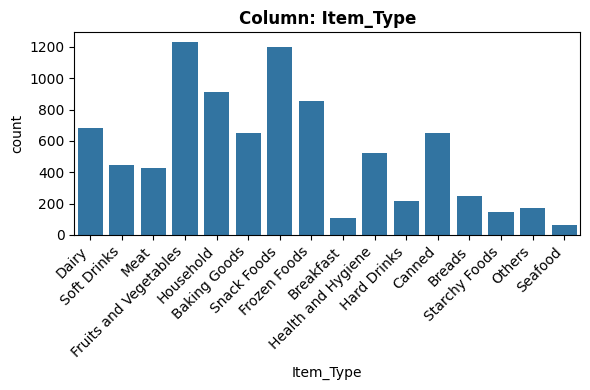

- NaN's Found: 0 (0.0%)
- Unique Values: 16
- Most common value: 'Fruits and Vegetables' occurs 1232 times (14.46%)
- Not constant or quasi-constant.


In [126]:
explore_categorical(df,'Item_Type');

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - Categorical (nominal)

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0 null values (0%).
  - No action needed.

3. Is the feature constant or quasi-constant?
  - Not constant or quasi-constant.

4. What is the cardinality? Is it high?
  - 16 unique values. Not high.

5. Would we know this BEFORE the target is determined?
  - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  - No.

/tmp/ipykernel_16475/166905199.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


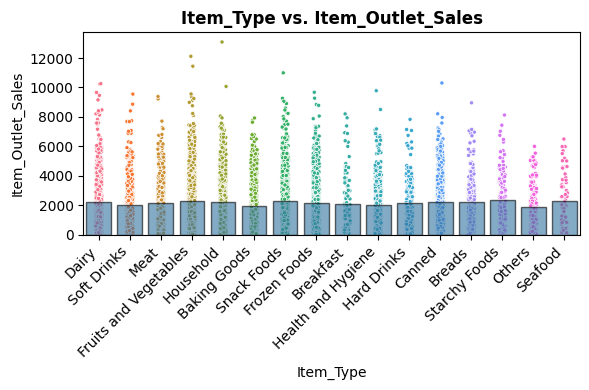

In [127]:
plot_categorical_vs_target(df, 'Item_Type','Item_Outlet_Sales');

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes, different item types would naturally have varying sales figures.
  - Does this feature appear to be a predictor of the target?
    - Yes, sales vary noticeably across different item types.

---

---

5. Item_MRP

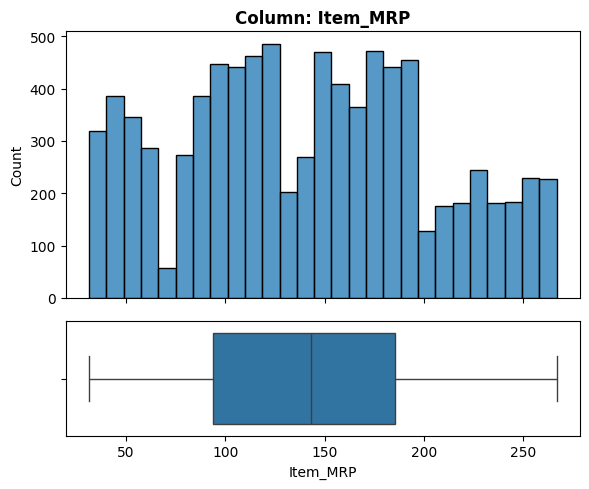

- NaN's Found: 0 (0.0%)
- Unique Values: 5938
- Most common value: '172.0422' occurs 7 times (0.08%)
- Not constant or quasi-constant.


In [128]:
explore_numeric(df,'Item_MRP');

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - Numeric

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0 null values (0%).
  - No action needed.

3. Is the feature constant or quasi-constant?
  - Not constant or quasi-constant.

4. What is the cardinality? Is it high?
  - 5938 unique values. High.

5. Would we know this BEFORE the target is determined?
  - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  - No.

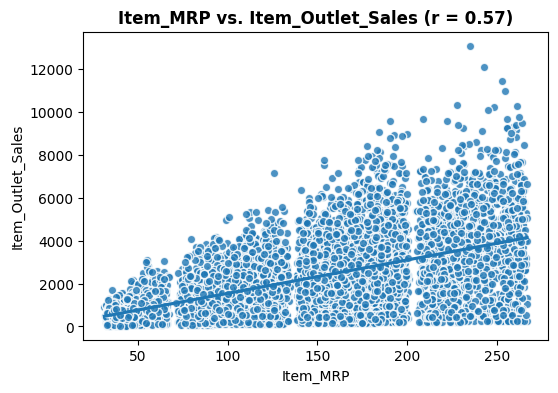

In [129]:
plot_numeric_vs_target(df,'Item_MRP', 'Item_Outlet_Sales');

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes, the maximum retail price (MRP) is a key factor influencing sales.
  - Does this feature appear to be a predictor of the target?
    - Yes, there is a strong positive correlation (r=0.57).

---

---

6. Outlet_Size

/tmp/ipykernel_16475/3512767888.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


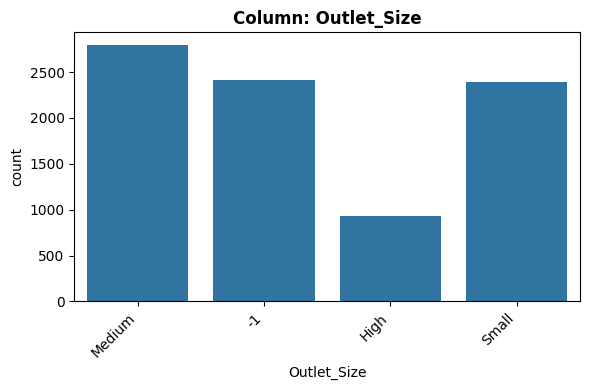

- NaN's Found: 0 (0.0%)
- Unique Values: 4
- Most common value: 'Medium' occurs 2793 times (32.77%)
- Not constant or quasi-constant.


In [130]:
explore_categorical(df,'Outlet_Size');

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - Categorical (nominal), though could be treated as ordinal if '-1' is handled appropriately.

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0 null values (0%).
  - Previously imputed with '-1'.

3. Is the feature constant or quasi-constant?
  - Not constant or quasi-constant.

4. What is the cardinality? Is it high?
  - 4 unique values. Not high.

5. Would we know this BEFORE the target is determined?
  - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  - No.

/tmp/ipykernel_16475/166905199.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


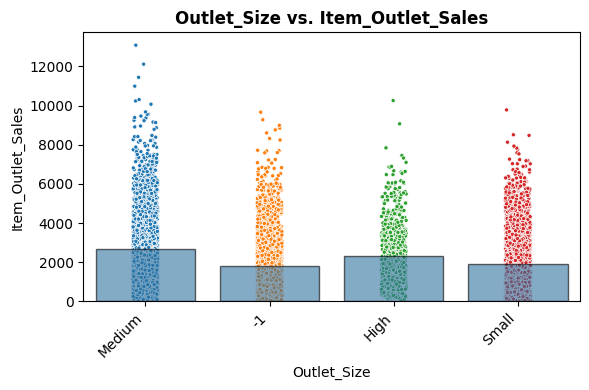

In [131]:
plot_categorical_vs_target(df, 'Outlet_Size','Item_Outlet_Sales');

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes, larger outlets might have higher sales volumes.
  - Does this feature appear to be a predictor of the target?
    - Yes, sales vary by outlet size, with 'Medium' outlets generally showing higher sales.

---

---

7. Outlet_Location_Type

/tmp/ipykernel_16475/3512767888.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


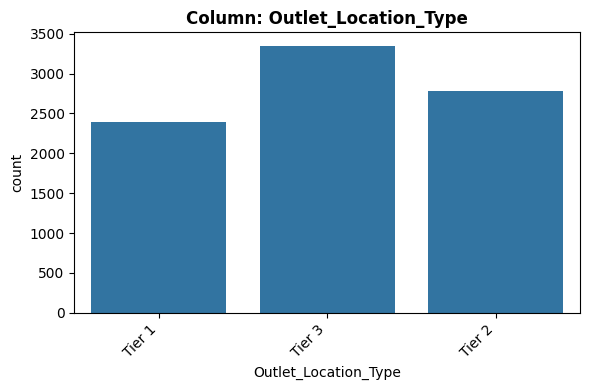

- NaN's Found: 0 (0.0%)
- Unique Values: 3
- Most common value: 'Tier 3' occurs 3350 times (39.31%)
- Not constant or quasi-constant.


In [132]:
explore_categorical(df,'Outlet_Location_Type');

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - Categorical (nominal)

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0 null values (0%).
  - No action needed.

3. Is the feature constant or quasi-constant?
  - Not constant or quasi-constant.

4. What is the cardinality? Is it high?
  - 3 unique values. Not high.

5. Would we know this BEFORE the target is determined?
  - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  - No.

/tmp/ipykernel_16475/166905199.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


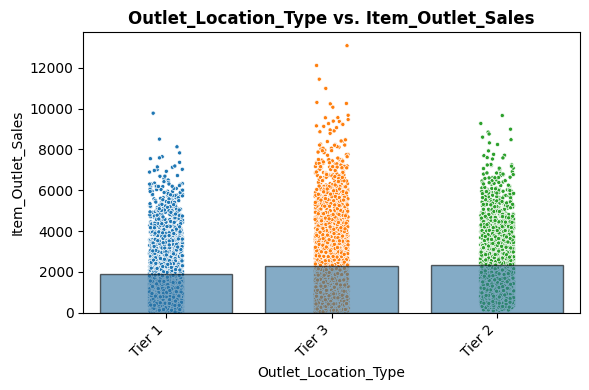

In [133]:
plot_categorical_vs_target(df, 'Outlet_Location_Type','Item_Outlet_Sales');

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes, the location type of an outlet could impact sales.
  - Does this feature appear to be a predictor of the target?
    - Yes, 'Tier 2' locations show slightly higher sales than 'Tier 1' or 'Tier 3'.

---

8. Outlet_Type

/tmp/ipykernel_16475/3512767888.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


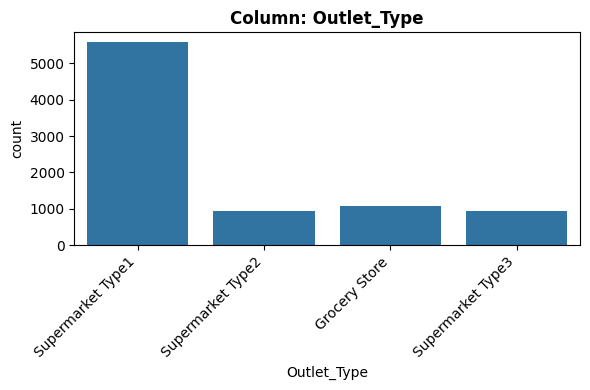

- NaN's Found: 0 (0.0%)
- Unique Values: 4
- Most common value: 'Supermarket Type1' occurs 5577 times (65.43%)
- Not constant or quasi-constant.


In [134]:
explore_categorical(df,'Outlet_Type');

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - Categorical (nominal)

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0 null values (0%).
  - No action needed.

3. Is the feature constant or quasi-constant?
  - Not constant or quasi-constant.

4. What is the cardinality? Is it high?
  - 4 unique values. Not high.

5. Would we know this BEFORE the target is determined?
  - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  - No.

/tmp/ipykernel_16475/166905199.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


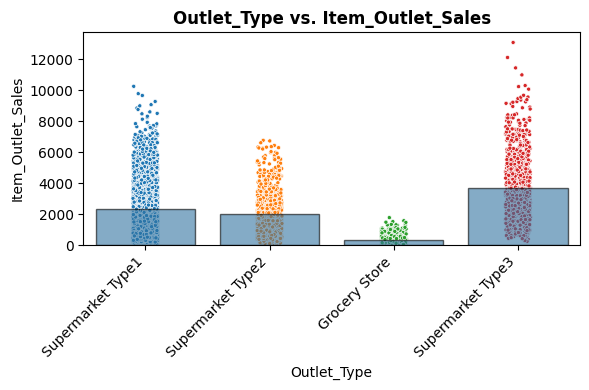

In [135]:
plot_categorical_vs_target(df, 'Outlet_Type','Item_Outlet_Sales');

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes, different outlet types would likely have different sales strategies and performance.
  - Does this feature appear to be a predictor of the target?
    - Yes, 'Supermarket Type3' has significantly higher sales compared to other outlet types.

---

---

9. Item_Outlet_Sales

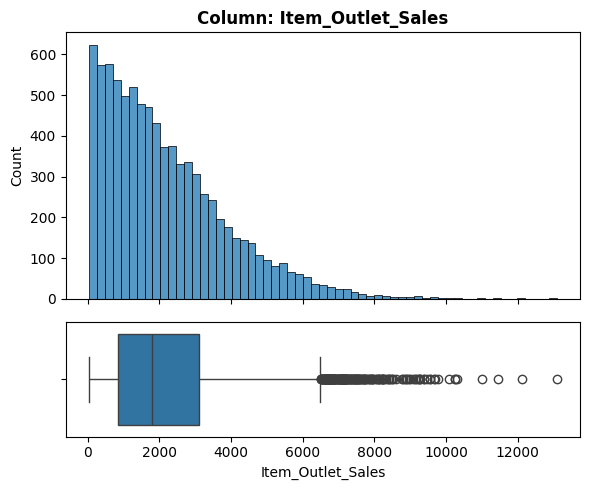

- NaN's Found: 0 (0.0%)
- Unique Values: 3493
- Most common value: '958.752' occurs 17 times (0.2%)
- Not constant or quasi-constant.


In [136]:
explore_numeric(df,'Item_Outlet_Sales');

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - Numeric (Target variable)

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0 null values (0%).
  - No action needed as this is the target.

3. Is the feature constant or quasi-constant?
  - Not constant or quasi-constant.

4. What is the cardinality? Is it high?
  - 3493 unique values. High.

5. Would we know this BEFORE the target is determined?
  - No, this is the target variable itself.

6. Is there a business case/understanding reason to exclude based on our business case?
  - No.

# Modeling

## Project 1 - Part 6 (Core)

In [179]:
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.preprocessing import OneHotEncoder,StandardScaler , OrdinalEncoder
from sklearn.compose import ColumnTransformer,make_column_transformer,make_column_selector
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [167]:
from sklearn import set_config
set_config(transform_output='pandas')

In [138]:
df_2.info()
df_2.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [139]:
df_2.nunique()

,0
Item_Identifier,1559
Item_Weight,415
Item_Fat_Content,5
Item_Visibility,7880
Item_Type,16
Item_MRP,5938
Outlet_Identifier,10
Outlet_Establishment_Year,9
Outlet_Size,3
Outlet_Location_Type,3


In [141]:
df_2.duplicated().sum()

np.int64(0)

In [142]:
df_2.isna().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [144]:
df_2 = df_2.drop('Item_Identifier', axis=1)

In [145]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Weight                7060 non-null   float64
 1   Item_Fat_Content           8523 non-null   object 
 2   Item_Visibility            8523 non-null   float64
 3   Item_Type                  8523 non-null   object 
 4   Item_MRP                   8523 non-null   float64
 5   Outlet_Identifier          8523 non-null   object 
 6   Outlet_Establishment_Year  8523 non-null   int64  
 7   Outlet_Size                6113 non-null   object 
 8   Outlet_Location_Type       8523 non-null   object 
 9   Outlet_Type                8523 non-null   object 
 10  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(6)
memory usage: 732.6+ KB


In [149]:
categorical_cols = df_2.select_dtypes(include=['object']).columns
categorical_cols

Index(['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size',
       'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

In [151]:
for col in categorical_cols:
    print(f"Unique values in '{col}':")
    print(df_2[col].unique())
    print("-" * 30)

Unique values in 'Item_Fat_Content':
['Low Fat' 'Regular' 'low fat' 'LF' 'reg']
------------------------------
Unique values in 'Item_Type':
['Dairy' 'Soft Drinks' 'Meat' 'Fruits and Vegetables' 'Household'
 'Baking Goods' 'Snack Foods' 'Frozen Foods' 'Breakfast'
 'Health and Hygiene' 'Hard Drinks' 'Canned' 'Breads' 'Starchy Foods'
 'Others' 'Seafood']
------------------------------
Unique values in 'Outlet_Identifier':
['OUT049' 'OUT018' 'OUT010' 'OUT013' 'OUT027' 'OUT045' 'OUT017' 'OUT046'
 'OUT035' 'OUT019']
------------------------------
Unique values in 'Outlet_Size':
['Medium' nan 'High' 'Small']
------------------------------
Unique values in 'Outlet_Location_Type':
['Tier 1' 'Tier 3' 'Tier 2']
------------------------------
Unique values in 'Outlet_Type':
['Supermarket Type1' 'Supermarket Type2' 'Grocery Store'
 'Supermarket Type3']
------------------------------


In [152]:
df_2['Item_Fat_Content'] = df_2['Item_Fat_Content'].replace(['low fat', 'LF'], 'Low Fat')
df_2['Item_Fat_Content'] = df_2['Item_Fat_Content'].replace(['reg'], 'Regular')

In [153]:
print(df_2['Item_Fat_Content'].value_counts())

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64


In [154]:
y = df_2['Item_Outlet_Sales']
X = df_2.drop('Item_Outlet_Sales', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42)

In [155]:
X.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2
2,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1
3,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store
4,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1


In [158]:
X_train.isna().sum()

,0
Item_Weight,1107
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,1812
Outlet_Location_Type,0
Outlet_Type,0


In [168]:
num_cols = X_train.select_dtypes('number').columns
num_impute = SimpleImputer(strategy='median')
num_scaler = StandardScaler()
num_pipe = make_pipeline(num_impute , num_scaler)
num_tuple = ('num' , num_pipe , num_cols)
num_tuple

('num',
 Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                 ('standardscaler', StandardScaler())]),
 Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
        'Outlet_Establishment_Year'],
       dtype='object'))

In [169]:
for col in categorical_cols:
    print(f"Unique values in '{col}':")
    print(X_train[col].unique())
    print("-" * 30)

Unique values in 'Item_Fat_Content':
['Low Fat' 'Regular']
------------------------------
Unique values in 'Item_Type':
['Household' 'Snack Foods' 'Meat' 'Baking Goods' 'Frozen Foods' 'Breads'
 'Canned' 'Fruits and Vegetables' 'Soft Drinks' 'Starchy Foods'
 'Health and Hygiene' 'Dairy' 'Hard Drinks' 'Breakfast' 'Seafood' 'Others']
------------------------------
Unique values in 'Outlet_Identifier':
['OUT018' 'OUT049' 'OUT035' 'OUT045' 'OUT019' 'OUT027' 'OUT046' 'OUT010'
 'OUT017' 'OUT013']
------------------------------
Unique values in 'Outlet_Size':
['Medium' 'Small' nan 'High']
------------------------------
Unique values in 'Outlet_Location_Type':
['Tier 3' 'Tier 1' 'Tier 2']
------------------------------
Unique values in 'Outlet_Type':
['Supermarket Type2' 'Supermarket Type1' 'Grocery Store'
 'Supermarket Type3']
------------------------------


In [170]:
ord_cols = ['Outlet_Size', 'Outlet_Location_Type']
ordinal_categories = [['Small', 'Medium', 'High'],
                      ['Tier 1', 'Tier 2', 'Tier 3']]

ord_impute = SimpleImputer(strategy='most_frequent')
ord_encoder = OrdinalEncoder(categories=ordinal_categories)
ord_scaler = StandardScaler()
ord_pipe = make_pipeline(ord_impute , ord_encoder , ord_scaler)
ord_tuple = ('ordinal' , ord_pipe , ord_cols)

In [171]:
cat_cols = X_train.select_dtypes('object').drop(columns = ord_cols).columns
cat_impute = SimpleImputer(strategy='most_frequent')
cat_encoder = OneHotEncoder(sparse_output=False , handle_unknown='ignore')
cat_pipe = make_pipeline(cat_impute , cat_encoder)
cat_tuple = ('categorical' , cat_pipe , cat_cols)

In [172]:
preprocessor = ColumnTransformer([num_tuple, ord_tuple, cat_tuple],
                                     verbose_feature_names_out=False)

In [175]:
def regression_metrics(y_true, y_pred, label='', verbose = True, output_dict=False):
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  r_squared = r2_score(y_true, y_pred)
  if verbose == True:
    header = "-"*60
    print(header, f"Regression Metrics: {label}", header, sep='\n')
    print(f"- MAE = {mae:,.3f}")
    print(f"- MSE = {mse:,.3f}")
    print(f"- RMSE = {rmse:,.3f}")
    print(f"- R^2 = {r_squared:,.3f}")
  if output_dict == True:
      metrics = {'Label':label, 'MAE':mae,
                 'MSE':mse, 'RMSE':rmse, 'R^2':r_squared}
      return metrics

def evaluate_regression(reg, X_train, y_train, X_test, y_test, verbose = True,
                        output_frame=False):
  y_train_pred = reg.predict(X_train)

  results_train = regression_metrics(y_train, y_train_pred, verbose = verbose,
                                     output_dict=output_frame,
                                     label='Training Data')
  print()
  y_test_pred = reg.predict(X_test)
  results_test = regression_metrics(y_test, y_test_pred, verbose = verbose,
                                  output_dict=output_frame,
                                    label='Test Data' )

  if output_frame:
    results_df = pd.DataFrame([results_train,results_test])
    results_df = results_df.set_index('Label')
    results_df.index.name=None
    return results_df.round(3)

In [176]:
lin_reg = LinearRegression()
lin_reg_pipe = make_pipeline(preprocessor , lin_reg)
lin_reg_pipe.fit(X_train , y_train)
evaluate_regression(lin_reg_pipe, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 847.129
- MSE = 1,297,558.136
- RMSE = 1,139.104
- R^2 = 0.562

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 804.120
- MSE = 1,194,349.715
- RMSE = 1,092.863
- R^2 = 0.567


1. Compare the training vs. test R-squared values and answer the question: to what extent is this model overfit/underfit?
-  The Training R² (0.562) and Test R² (0.567) are nearly identical.
- The model is underfitting. There is no overfitting (since the scores are consistent), but the low R² indicates the linear model is too simple to capture the complex patterns in the data.

In [180]:
rf = RandomForestRegressor(random_state = 42)
rf_pipe = make_pipeline(preprocessor, rf)
rf_pipe.fit(X_train, y_train)
evaluate_regression(rf_pipe, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 296.473
- MSE = 182,503.660
- RMSE = 427.204
- R^2 = 0.938

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 767.140
- MSE = 1,218,088.531
- RMSE = 1,103.670
- R^2 = 0.558


1. Compare the training vs. test R-squared values and answer the question: to what extent is this model overfit/underfit?
- The Training R² (0.938) is significantly higher than the Test R² (0.558).
- The model is severely overfitting. It learned the training data almost perfectly but failed to generalize to the test data.

2. which model has the best test scores?
- The Linear Regression model has the best test score (0.567 compared to 0.558). The default Random Forest is currently too complex and overfit to outperform the simple linear model on unseen data.

In [183]:
param_grid = {'randomforestregressor__max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, None],
              'randomforestregressor__min_samples_leaf': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'randomforestregressor__min_samples_split': [2, 3, 4]}

In [185]:
grid_search = GridSearchCV(rf_pipe, param_grid, n_jobs = -1, verbose = 1)

In [186]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 330 candidates, totalling 1650 fits


GridSearchCV(estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('standardscaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year'],
      dtype='object')),
                                                                        ('ordinal',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          Simple...
                                                                         Index(['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Type'], dtype='object'))],
                                                          verbose_feature_names_out=False)),
                                       ('randomforestregressor',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'randomforestregressor__max_depth': [1, 2, 3, 4, 5, 6,
                                                              7, 8, 9, 10,
                                                              None],
                         'randomforestregressor__min_samples_leaf': [1, 2, 3, 4,
                                                                     5, 6, 7, 8,
                                                                     9, 10],
                         'randomforestregressor__min_samples_split': [2, 3, 4]},
             verbose=1)

In [187]:
grid_search.best_params_

{'randomforestregressor__max_depth': 5,
 'randomforestregressor__min_samples_leaf': 1,
 'randomforestregressor__min_samples_split': 2}

In [188]:
best_model = grid_search.best_estimator_
evaluate_regression(best_model, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 755.393
- MSE = 1,152,591.475
- RMSE = 1,073.588
- R^2 = 0.611

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 728.407
- MSE = 1,096,400.973
- RMSE = 1,047.092
- R^2 = 0.603


1. Compare your tuned model to your default Random Forest: did the performance improve?
- The tuning successfully eliminated the severe overfitting seen in the default model (the gap between Train and Test R² dropped from 0.38 to just 0.008).
- The tuned Random Forest now has the best overall test score (0.603), outperforming both the default Random Forest (0.558) and the Linear Regression model (0.567).

-----------------

1. Overall, which model do you recommend?
- I recommend the Tuned Random Forest model.
2. Justify your recommendation:
- It achieved the highest test score (R² = 0.603) compared to both the Linear Regression (0.567) and the default Random Forest (0.558). Most importantly, tuning successfully eliminated the severe overfitting issue of the default model.
3. Interpret R-squared for a non-technical stakeholder:
- An R² of 0.603 means our model can explain about 60% of the reasons why sales vary across different products and outlets. The remaining 40% is due to external factors we don't have data for (such as local promotions or seasonal trends).
4. Select another regression metric & explain why:
- I selected MAE (Mean Absolute Error). I chose MAE because it is the easiest to understand—it shows the average dollar mistake without being overly complicated by outliers like RMSE.
5. Compare training vs. test scores (Overfit/Underfit):
- The model is very stable with slight underfitting. The training R² (0.611) and test R² (0.603) are almost identical, meaning there is zero overfitting. However, because both scores are around 60%, the model is missing some complex patterns in the data (slight underfitting), which is much better than memorizing the data.


